<a href="https://colab.research.google.com/github/PrantoHalder/An-Efficient-Model-for-Parkinson-s-Disease-Prediction/blob/main/An_Efficient_Model_for_Parkinson's_Disease_Prediction_and_Categorization_Using_Quantum_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:09:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


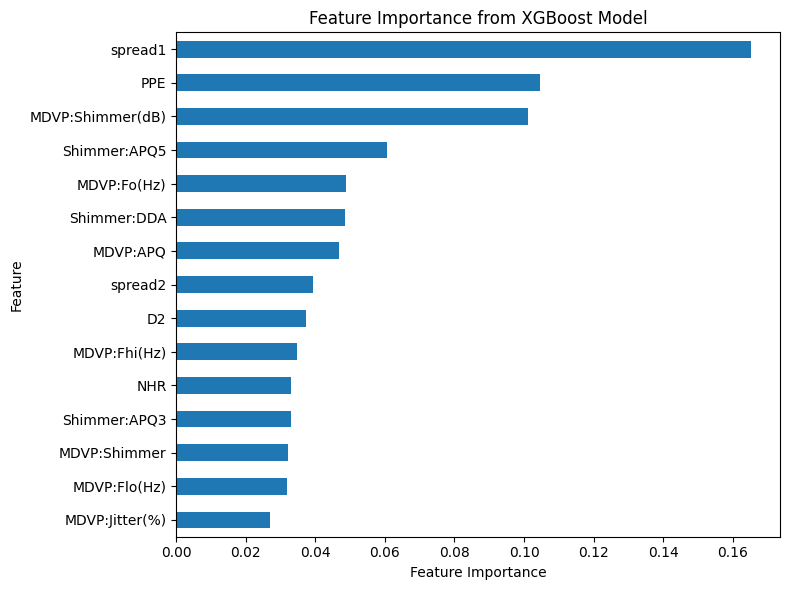

In [ ]:
# figure4_feature_importance.py

import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import os

# === 1. Load the dataset ===
# Make sure 'parkinsons.data' is in the same folder as this script
data_path = "/content/parkinsons.data"
df = pd.read_csv(data_path)

# Drop non-feature columns and separate label
X = df.drop(columns=["name", "status"])
y = df["status"]

# === 2. Train XGBoost model ===
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",  # to avoid deprecation warnings
)

model.fit(X, y)

# === 3. Compute feature importance ===
importances = model.feature_importances_
fi = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# === 4. Plot and save Figure 4 ===
plt.figure(figsize=(8, 6))
fi.head(15).plot(kind="barh")
plt.gca().invert_yaxis()  # most important at the top
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance from XGBoost Model")
plt.tight_layout()

# Save as PNG (you can also save


In [ ]:
# figure5_confusion_matrix.py

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb

# === 1. Load the dataset ===
data_path = "parkinsons.data"  # make sure this file is in the same folder
df = pd.read_csv(data_path)

# Separate features and label
X = df.drop(columns=["name", "status"])
y = df["status"]  # 1 = PD, 0 = Healthy

# === 2. Train–test split (70% train, 30% test, stratified) ===
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42,
)

# === 3. Train XGBoost classifier (you can tune hyperparameters as needed) ===
clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
)

clf.fit(X_train, y_train)

# === 4. Predict on the test set ===
y_pred = clf.predict(X_test)

# === 5. Compute confusion matrix ===
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# === 6. Plot and save Figure 5 ===
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy (0)", "PD (1)"]
)

plt.figure(figsize=(5, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix of the PD Classifier")
plt.tight_layout()

output_filename = "figure5_confusion_matrix.png"
plt.savefig(output_filename, dpi=300)

print(f"Figure 5 saved as: {os.path.abspath(output_filename)}")
plt.close()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:20:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Figure 5 saved as: /content/figure5_confusion_matrix.png


<Figure size 500x500 with 0 Axes>

In [ ]:
# figure6_correlation_heatmap.py

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # pip install seaborn

# === 1. Load the dataset ===
data_path = "parkinsons.data"  # make sure this file is in the same folder
df = pd.read_csv(data_path)

# === 2. Select relevant features for the heatmap ===
# We select core vocal and nonlinear features commonly used in PD voice analysis
features = [
    "MDVP:Fo(Hz)",
    "MDVP:Fhi(Hz)",
    "MDVP:Flo(Hz)",
    "MDVP:Jitter(%)",
    "MDVP:Shimmer",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "spread1",
    "spread2",
    "D2",
    "PPE",
    "status",  # label included to show correlation with diagnosis
]

df_sel = df[features]

# === 3. Compute correlation matrix (Pearson) ===
corr = df_sel.corr(method="pearson")

# === 4. Plot correlation heatmap ===
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=False,        # set to True if you want numbers in each cell
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8},
    linewidths=0.5,
)

plt.title("Correlation Heatmap of Key Vocal and Nonlinear Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# === 5. Save figure ===
output_filename = "figure6_correlation_heatmap.png"
plt.savefig(output_filename, dpi=300)

print(f"Figure 6 saved as: {os.path.abspath(output_filename)}")
plt.close()


Figure 6 saved as: /content/figure6_correlation_heatmap.png


In [ ]:
# figure8_roc_curve.py

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import xgboost as xgb

# === 1. Load the dataset ===
data_path = "parkinsons.data"  # file must be in the same folder
df = pd.read_csv(data_path)

# Separate features and labels
X = df.drop(columns=["name", "status"])
y = df["status"]

# === 2. Split into train/test sets ===
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42,
)

# === 3. Train an XGBoost classifier ===
clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
)

clf.fit(X_train, y_train)

# === 4. Compute predicted probabilities for ROC ===
y_prob = clf.predict_proba(X_test)[:, 1]

# === 5. Compute ROC curve and AUC ===
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# === 6. Plot ROC Curve ===
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [1, 0], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of the Parkinson's Disease Classifier")
plt.legend(loc="lower right")
plt.tight_layout()

# === 7. Save High-Resolution Image (300 dpi) ===
output_filename = "figure8_roc_curve.png"
plt.savefig(output_filename, dpi=300)

print(f"Figure 8 saved as: {os.path.abspath(output_filename)}")
plt.close()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:47:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Figure 8 saved as: /content/figure8_roc_curve.png


In [ ]:
from google.colab import drive
drive.mount('/content/drive')